# Web Scraping - Seu Dinheiro


## Imports e configurações

In [123]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import json
import pathlib

In [124]:
base_url = "https://www.seudinheiro.com"
url_listagem = f"{base_url}/ultimas/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
}

## Diagnóstico



## Status pagina inicial

In [125]:
resp_lista = requests.get(url_listagem, headers=headers, timeout=20)
print(f"Status HTTP: {resp_lista.status_code}")
print(f"URL final: {resp_lista.url}")
print(f"Tamanho do HTML: {len(resp_lista.text)} caracteres")

Status HTTP: 200
URL final: https://www.seudinheiro.com/ultimas/
Tamanho do HTML: 111659 caracteres


## 20 noticias por pag

In [126]:
soup_lista = BeautifulSoup(resp_lista.text, "html.parser")

itens = soup_lista.find_all("div", class_="stream-item-container")
print(f"Itens de notícia encontrados na página 1: {len(itens)}")

Itens de notícia encontrados na página 1: 20


## Uma noticia qualquer

In [127]:
primeiro_item = soup_lista.find("div", class_="stream-item-container")

a_titulo = primeiro_item.find("h2", class_="feed_content_title").find("a")
link_teste = a_titulo["href"]
link_teste

'https://www.seudinheiro.com/2026/lifestyle/europa-novo-sistema-de-imigracao-pode-atrasar-entrada-em-ate-3-horas-veja-como-se-preparar-lefp/'

## Noticia desbloqueada

In [128]:
print(f"Testando notícia individual: {link_teste}")

resp_noticia = requests.get(link_teste, headers=headers, timeout=20)
print(f"Status HTTP da notícia: {resp_noticia.status_code}")

Testando notícia individual: https://www.seudinheiro.com/2026/lifestyle/europa-novo-sistema-de-imigracao-pode-atrasar-entrada-em-ate-3-horas-veja-como-se-preparar-lefp/
Status HTTP da notícia: 200


In [129]:
soup_noticia = BeautifulSoup(resp_noticia.text, "html.parser")
soup_noticia

<!DOCTYPE html>

<html lang="pt-br">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<meta content="ie=edge" http-equiv="x-ua-compatible"/>
<meta content="328048117752707" property="fb:app_id">
<meta content="Seu Dinheiro" name="publisher">
<link href="https://fonts.googleapis.com" rel="preconnect"/>
<link crossorigin="" href="https://fonts.gstatic.com" rel="preconnect"/>
<link href="https://fonts.googleapis.com/css2?family=Barlow:ital,wght@0,400;0,500;0,600;0,700;1,400;1,500;1,600;1,700&amp;family=Raleway:ital,wght@0,400;0,500;0,600;0,700;1,400;1,500;1,600;1,700&amp;display=block" rel="stylesheet"/>
<meta content="index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1" name="robots">
<style>img:is([sizes="auto" i], [sizes^="auto," i]) { contain-intrinsic-size: 3000px 1500px }</style>
<!-- This site is optimized with the Yoast SEO Premium plugin v27.0 (Yoast SEO v27.2) - https://yoast.com/product/yoast-seo-premi

## Titulo

In [130]:
titulo = soup_noticia.find("h1", class_="newSingle_header_title")
print(titulo)
print()
print(titulo.get_text(strip=True))

<h1 class="newSingle_header_title">Europa: novo sistema de imigração pode atrasar entrada em até 3 horas — veja como se preparar</h1>

Europa: novo sistema de imigração pode atrasar entrada em até 3 horas — veja como se preparar


## Subtitulo

In [131]:
subtitulo = soup_noticia.find("div", class_="newSingle_header_excerpt")
print(subtitulo)
print()
print(subtitulo.get_text(strip=True))

<div class="newSingle_header_excerpt"><p>Novo sistema de entrada e saída no continente exige registro biométrico e provoca filas de até 3 horas em aeroportos; saiba como evitar perrengues na sua próxima viagem</p>
</div>

Novo sistema de entrada e saída no continente exige registro biométrico e provoca filas de até 3 horas em aeroportos; saiba como evitar perrengues na sua próxima viagem


## Data e Hora

In [132]:
data_hora = soup_noticia.find("div", class_="single__date-time")
print(data_hora)
print()
print(data_hora.get_text(strip=True))

<div class="js-first-letter single__date-time">
					20 de abril de 2026					<span class="single__time">
<div class="single__clock-icon">
<img alt="" height="16" loading="lazy" src="https://www.seudinheiro.com/app/themes/seudinheiro/build/icons/icon-clock.svg" width="16"/> </div>

						15:30											</span>
</div>

20 de abril de 202615:30


In [133]:
import re

texto_data_hora = data_hora.get_text(strip=True)

data = re.search(r"\d{1,2} de [a-zç]+ de \d{4}", texto_data_hora, flags=re.IGNORECASE)
hora = re.search(r"\d{1,2}:\d{2}", texto_data_hora)


print(data.group())
print(hora.group())
## Lembrar de tratar data


20 de abril de 2026
15:30


In [134]:
from datetime import datetime

texto_data = "20 de abril de 2026"

meses = {
    "janeiro": "01",
    "fevereiro": "02",
    "março": "03",
    "abril": "04",
    "maio": "05",
    "junho": "06",
    "julho": "07",
    "agosto": "08",
    "setembro": "09",
    "outubro": "10",
    "novembro": "11",
    "dezembro": "12"
}

partes = texto_data.lower().split(" de ")
dia = partes[0]
mes = meses[partes[1]]
ano = partes[2]

data_formatada = f"{ano}-{mes}-{dia.zfill(2)}"

print(data_formatada)

2026-04-20


## Primeiras impressoes de um possivel db

In [135]:
import pandas as pd

banco_noticias = {
    "titulo": titulo.get_text(' ',strip=True),
    "subtitulo": subtitulo.get_text(" ", strip=True),
    "data_texto": data_formatada,
    "hora_texto": hora.group(),
}

print(banco_noticias)

{'titulo': 'Europa: novo sistema de imigração pode atrasar entrada em até 3 horas — veja como se preparar', 'subtitulo': 'Novo sistema de entrada e saída no continente exige registro biométrico e provoca filas de até 3 horas em aeroportos; saiba como evitar perrengues na sua próxima viagem', 'data_texto': '2026-04-20', 'hora_texto': '15:30'}


## Adicionando informacoes do autor

In [136]:
autor = soup_noticia.find("div", class_="newSingle_author_info_content_title")
print(autor.get_text(' ',strip=True))

Letícia Flávia Pinheiro


In [137]:
descricao_autor = soup_noticia.find("p", class_="author-bio__text")

descricao_autor_texto = descricao_autor.get_text(" ", strip=True) if descricao_autor else None

In [138]:
banco_noticias = {
    "titulo": titulo.get_text(strip=True), ## Tem um \ax0 no texto do titulo, verificar 
    "subtitulo": subtitulo.get_text(" ", strip=True),
    "data_texto": data_formatada,
    "hora_texto": hora.group(),
    'autor': autor.get_text(strip=True),
    'descricao_autor': descricao_autor_texto ## Existem descricoes que sao nulas
}
banco_noticias

{'titulo': 'Europa: novo sistema de imigração pode atrasar entrada em até 3 horas — veja como se preparar',
 'subtitulo': 'Novo sistema de entrada e saída no continente exige registro biométrico e provoca filas de até 3 horas em aeroportos; saiba como evitar perrengues na sua próxima viagem',
 'data_texto': '2026-04-20',
 'hora_texto': '15:30',
 'autor': 'Letícia Flávia Pinheiro',
 'descricao_autor': 'Jornalista formada pela Universidade de São Paulo (ECA-USP), apaixonada por arte, cultura e tendências. Já trabalhou com comunicação persuasiva e criativa para marcas como Claro, iFood, Pepsico, Tesouro Nacional e BTG Pactual.'}

## Informacoes do proprio texto

### Pegar caixa principal de noticias e limpar o que é propaganda, depois pegar só paragrafos (CONTINUA DEPOIS DA PUBLICIDADE, SAIBA MAIS)

In [139]:
corpo = soup_noticia.find("div", class_="newSingle_content_right")
print(corpo)

<div class="newSingle_content_right lifestyle" id="js-first-letter">
<!-- NOVO -->
<div class="newSingle-shareMobile">
<a class="newSingle-shareMobile-btn googlenews" href="https://news.google.com/publications/CAAqBwgKMKXMjwswrISjAw?hl=pt-BR&amp;gl=BR&amp;ceid=BR%3Apt-419" target="_blank">
<img alt="Google News" height="22" loading="lazy" src="https://www.seudinheiro.com/app/themes/seudinheiro/build/icons/icon-googlenews.svg" width="27"/>
</a>
<a class="newSingle-shareMobile-btn whatsapp" href="https://api.whatsapp.com/send?text=https%3A%2F%2Fwww.seudinheiro.com%2F2026%2Flifestyle%2Feuropa-novo-sistema-de-imigracao-pode-atrasar-entrada-em-ate-3-horas-veja-como-se-preparar-lefp%2F%3Fxpromo%3DXD-MI-SDW-MTSD-BWHATS-X-WHATS-X-X-X%26utm_source%3DSDW%26utm_medium%3DWHATS%26utm_campaign%3DXD-MI-SDW-MTSD-BWHATS-X-WHATS-X-X-X" target="_blank">
<img alt="Whatsapp" height="19" loading="lazy" src="https://www.seudinheiro.com/app/themes/seudinheiro/build/icons/icon-whatsapp-white.svg" width="19"/>


In [140]:
classes_lixo = [
    "borderAD",
    "ad-inview",
    "newSingle_readtoo",
    "newSingle_readtoo_article",
    "newSingle-shareMobile",
    "single__footer-author",
    "content-tags",
    "single__first-letter",
]

for classe in classes_lixo:
    for tag in corpo.find_all(class_=classe):
        tag.decompose()

blocos = corpo.find_all('p')

lista_textos = []

for bloco in blocos:
    texto = bloco.get_text(" ", strip=True)

    if not texto:
        continue

    if texto.startswith("CONFIRA:"):
        continue

    if texto.startswith("SAIBA MAIS:"):
        continue

    lista_textos.append(texto)

texto_noticia = " ".join(lista_textos)

print(texto_noticia)


Desde o dia 10 de abril, o Entry/Exit System ( EES ), novo sistema de controle migratório da Europa, passou a valer oficialmente em 29 países do continente. A mudança, no entanto, vem causando transtornos aos viajantes, que estão enfrentando filas longas e demoradas na imigração. De acordo com o Conselho Internacional de Aeroportos (ACI), desde o início da implementação do EES, passageiros têm enfrentado esperas de até três horas em ao menos 15 países , incluindo França, Alemanha, Itália, Espanha e Grécia. Com o novo sistema, o carimbo do passaporte é substituído por um controle 100% digital , mediante o registro da biometria facial, impressões digitais e dados pessoais em totens eletrônicos. Embora a medida aumente o controle e a segurança nas fronteiras, ela também torna o processo de entrada mais lento, já que os passageiros precisam se registrar individualmente na máquina. De acordo com a Comissão Europeia , órgão executivo da União Europeia , o tempo médio levado para um passageir

In [141]:
banco_noticias = {
    "titulo": titulo.get_text(strip=True), ## Tem um \ax0 no texto do titulo, verificar 
    "subtitulo": subtitulo.get_text(" ", strip=True),
    "data_texto": data_formatada,
    "hora_texto": hora.group(),
    'autor': autor.get_text(strip=True),
    'descricao_autor': descricao_autor_texto,
    'texto': texto_noticia 
}
banco_noticias

{'titulo': 'Europa: novo sistema de imigração pode atrasar entrada em até 3 horas — veja como se preparar',
 'subtitulo': 'Novo sistema de entrada e saída no continente exige registro biométrico e provoca filas de até 3 horas em aeroportos; saiba como evitar perrengues na sua próxima viagem',
 'data_texto': '2026-04-20',
 'hora_texto': '15:30',
 'autor': 'Letícia Flávia Pinheiro',
 'descricao_autor': 'Jornalista formada pela Universidade de São Paulo (ECA-USP), apaixonada por arte, cultura e tendências. Já trabalhou com comunicação persuasiva e criativa para marcas como Claro, iFood, Pepsico, Tesouro Nacional e BTG Pactual.',
 'texto': 'Desde o dia 10 de abril, o Entry/Exit System ( EES ), novo sistema de controle migratório da Europa, passou a valer oficialmente em 29 países do continente. A mudança, no entanto, vem causando transtornos aos viajantes, que estão enfrentando filas longas e demoradas na imigração. De acordo com o Conselho Internacional de Aeroportos (ACI), desde o início

### Aqui temos toda a dinamica necessaria para montar o banco de dados, agora devemos iterar para todas as noticias

## Estrutura de repeticao


### Funcoes Necessarias

#### Limpar Texto

In [142]:
import re
from datetime import datetime
import requests
from bs4 import BeautifulSoup

def limpar_texto(texto):
    if texto is None:
        return None
    
    texto = texto.replace("\xa0", " ")
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()



#### Converter Data Hora

In [143]:
def converter_data_hora(texto_data_hora):
    data_texto = None
    hora_texto = None
    data_iso = None

    if texto_data_hora is None:
        return data_texto, hora_texto, data_iso

    texto_data_hora = limpar_texto(texto_data_hora)

    data_match = re.search(r"\d{1,2} de [a-zç]+ de \d{4}", texto_data_hora, flags=re.IGNORECASE)
    hora_match = re.search(r"\d{1,2}:\d{2}", texto_data_hora)

    if data_match:
        data_texto = data_match.group()

        meses = {
            "janeiro": "01",
            "fevereiro": "02",
            "março": "03",
            "abril": "04",
            "maio": "05",
            "junho": "06",
            "julho": "07",
            "agosto": "08",
            "setembro": "09",
            "outubro": "10",
            "novembro": "11",
            "dezembro": "12"
        }

        partes = data_texto.lower().split(" de ")
        dia = partes[0]
        mes = meses[partes[1]]
        ano = partes[2]

        data_iso = f"{ano}-{mes}-{dia.zfill(2)}"

    if hora_match:
        hora_texto = hora_match.group()

    return data_texto, hora_texto, data_iso



#### Extrair Links de Paginas

In [144]:

def extrair_links_pagina(url_pagina, headers):
    resp = requests.get(url_pagina, headers=headers, timeout=20)
    soup = BeautifulSoup(resp.text, "html.parser")

    itens = soup.find_all("div", class_="stream-item-container")

    links = []

    for item in itens:
        h2 = item.find("h2", class_="feed_content_title")
        if h2:
            a_tag = h2.find("a")
            if a_tag and a_tag.has_attr("href"):
                links.append(a_tag["href"])

    return links

#### Extrair infos Noticias Unicas

In [145]:
def extrair_noticia_session(link, headers, session):
    resp_noticia = session.get(link, headers=headers, timeout=20)

    if resp_noticia.status_code != 200:
        raise Exception(f"HTTP {resp_noticia.status_code}")

    soup_noticia = BeautifulSoup(resp_noticia.text, "html.parser")

    # título
    titulo = soup_noticia.find("h1", class_="newSingle_header_title")
    titulo_texto = limpar_texto(titulo.get_text(" ", strip=True)) if titulo else None

    # subtítulo
    subtitulo = soup_noticia.find("div", class_="newSingle_header_excerpt")
    subtitulo_texto = limpar_texto(subtitulo.get_text(" ", strip=True)) if subtitulo else None

    # data e hora
    data_hora = soup_noticia.find("div", class_="single__date-time")
    texto_data_hora = limpar_texto(data_hora.get_text(" ", strip=True)) if data_hora else None
    data_texto, hora_texto, data_iso = converter_data_hora(texto_data_hora)

    # autor
    autor = soup_noticia.find("div", class_="newSingle_author_info_content_title")
    autor_texto = limpar_texto(autor.get_text(" ", strip=True)) if autor else None

    # descrição do autor
    descricao_autor = soup_noticia.find("p", class_="author-bio__text")
    descricao_autor_texto = limpar_texto(descricao_autor.get_text(" ", strip=True)) if descricao_autor else None

    # corpo da notícia
    corpo = soup_noticia.find("div", class_="newSingle_content_right")
    texto_noticia = None

    if corpo:
        classes_lixo = [
            "borderAD",
            "ad-inview",
            "newSingle_readtoo",
            "newSingle_readtoo_article",
            "newSingle-shareMobile",
            "single__footer-author",
            "content-tags",
            "single__first-letter",
        ]

        for classe in classes_lixo:
            for tag in corpo.find_all(class_=classe):
                tag.decompose()

        blocos = corpo.find_all("p")

        lista_textos = []

        for bloco in blocos:
            texto = limpar_texto(bloco.get_text(" ", strip=True))

            if not texto:
                continue

            if texto.startswith("CONFIRA:"):
                continue

            if texto.startswith("SAIBA MAIS:"):
                continue

            lista_textos.append(texto)

        texto_noticia = "\n\n".join(lista_textos)

    return {
        "url": link,
        "titulo": titulo_texto,
        "subtitulo": subtitulo_texto,
        "data_texto": data_texto,
        "hora_texto": hora_texto,
        "data_iso": data_iso,
        "autor": autor_texto,
        "descricao_autor": descricao_autor_texto,
        "texto": texto_noticia
    }

#### Extrair Infos noticia individual paralelizando

In [146]:
import re
import time
import random
import requests
import pandas as pd

from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed

In [147]:
def worker_extrair_noticia(item, headers):
    link = item["url"]
    pagina = item["pagina_origem"]

    with requests.Session() as session:
        dados = extrair_noticia_session(link, headers, session)

    dados["pagina_origem"] = pagina
    return dados

In [158]:
base_url = "https://www.seudinheiro.com"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
}

# 1) coletar links das 3 páginas
todos_links = []

for pagina in range(301, 600):
    if pagina == 1:
        url_pagina = f"{base_url}/ultimas/"
    else:
        url_pagina = f"{base_url}/ultimas/pagina/{pagina}/"

    print(f"\nColetando links da página {pagina}: {url_pagina}")

    try:
        links = extrair_links_pagina(url_pagina, headers)
        print(f"Links encontrados: {len(links)}")

        for link in links:
            todos_links.append({
                "url": link,
                "pagina_origem": pagina
            })

        time.sleep(random.uniform(1, 2))

    except Exception as e:
        print(f"Erro ao coletar links da página {pagina}: {e}")

print(f"\nTotal de links coletados: {len(todos_links)}")


Coletando links da página 301: https://www.seudinheiro.com/ultimas/pagina/301/
Links encontrados: 20

Coletando links da página 302: https://www.seudinheiro.com/ultimas/pagina/302/
Links encontrados: 20

Coletando links da página 303: https://www.seudinheiro.com/ultimas/pagina/303/
Links encontrados: 20

Coletando links da página 304: https://www.seudinheiro.com/ultimas/pagina/304/
Links encontrados: 20

Coletando links da página 305: https://www.seudinheiro.com/ultimas/pagina/305/
Links encontrados: 20

Coletando links da página 306: https://www.seudinheiro.com/ultimas/pagina/306/
Links encontrados: 20

Coletando links da página 307: https://www.seudinheiro.com/ultimas/pagina/307/
Links encontrados: 20

Coletando links da página 308: https://www.seudinheiro.com/ultimas/pagina/308/
Links encontrados: 20

Coletando links da página 309: https://www.seudinheiro.com/ultimas/pagina/309/
Links encontrados: 20

Coletando links da página 310: https://www.seudinheiro.com/ultimas/pagina/310/
Li

In [159]:
registros = []

max_workers = 4

print(f"\nIniciando extração paralela com {max_workers} threads...")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futuros = [
        executor.submit(worker_extrair_noticia, item, headers)
        for item in todos_links
    ]

    for i, futuro in enumerate(as_completed(futuros), start=1):
        try:
            dados = futuro.result()
            registros.append(dados)

            print(f"[{i}/{len(futuros)}] OK")
            print(f"  Página: {dados['pagina_origem']}")
            print(f"  Título: {dados['titulo']}")
            print(f"  Data: {dados['data_texto']} | Hora: {dados['hora_texto']}")
            print(f"  Autor: {dados['autor']}")
            print(f"  Texto tamanho: {len(dados['texto']) if dados['texto'] else 0}")

        except Exception as e:
            print(f"[{i}/{len(futuros)}] ERRO: {e}")


Iniciando extração paralela com 4 threads...
[1/5980] OK
  Página: 301
  Título: Ele passou 5 anos em fuga sob suspeita de roubar R$ 70 milhões em criptomoedas — e acabou na cadeia por causa de uma bituca de cigarro
  Data: 22 de agosto de 2025 | Hora: 10:01
  Autor: Ricardo Gozzi
  Texto tamanho: 1515
[2/5980] OK
  Página: 301
  Título: Mega-Sena 2904 acumula e pode pagar R$ 28 milhões amanhã; Lotofácil 3475 e Quina 6806 também emperram e prêmios em jogo aumentam
  Data: 22 de agosto de 2025 | Hora: 9:18
  Autor: Isabelle Miranda
  Texto tamanho: 904
[3/5980] OK
  Página: 301
  Título: Nelson Tanure perde exclusividade na Braskem (BRKM5), mas continua negociando compra do controle — com uma condição crítica
  Data: 22 de agosto de 2025 | Hora: 10:13
  Autor: Camille Lima
  Texto tamanho: 4935
[4/5980] OK
  Página: 301
  Título: Compra do Banco Master pode render lucro de R$ 1,5 bilhão para o BRB em 5 anos — pelo menos, é o que prevê a instituição estatal
  Data: 22 de agosto de 2025 

In [160]:
df_noticias = pd.DataFrame(registros)

print(f"\nTotal de notícias extraídas com sucesso: {len(df_noticias)}")
df_noticias.head(3)


Total de notícias extraídas com sucesso: 5980


,url,titulo,subtitulo,data_texto,hora_texto,data_iso,autor,descricao_autor,texto,pagina_origem
0,https://www.seudinheiro.com/2025/criptomoedas/...,Ele passou 5 anos em fuga sob suspeita de roub...,Suspeito teria lesado cerca de 1.300 pessoas e...,22 de agosto de 2025,10:01,2025-08-22,Ricardo Gozzi,É jornalista e escritor. Passou quase 20 anos ...,Imagine passar cinco anos em fuga sob suspeita...,301
1,https://www.seudinheiro.com/2025/economia/mega...,Mega-Sena 2904 acumula e pode pagar R$ 28 milh...,Nenhum apostador cravou as dezenas premiadas n...,22 de agosto de 2025,9:18,2025-08-22,Isabelle Miranda,"Jornalista com pós-graduação em Literatura, Ar...",A sorte não sorriu para os apostadores nos últ...,301
2,https://www.seudinheiro.com/2025/empresas/nels...,Nelson Tanure perde exclusividade na Braskem (...,"Uma fonte no Fundo Petroquímica Verde, de Tanu...",22 de agosto de 2025,10:13,2025-08-22,Camille Lima,Jornalista formada pela Universidade Municipal...,O período de exclusividade para as negociações...,301


In [ ]:
df_noticias = pd.DataFrame(registros)
print(df_noticias.shape)
df_noticias.head()
# df_noticias.to_csv(r"noticias_seu_dinheiro_paralelo_pag301_600.csv" ,index=False)

(5980, 10)


,url,titulo,subtitulo,data_texto,hora_texto,data_iso,autor,descricao_autor,texto,pagina_origem
0,https://www.seudinheiro.com/2025/criptomoedas/...,Ele passou 5 anos em fuga sob suspeita de roub...,Suspeito teria lesado cerca de 1.300 pessoas e...,22 de agosto de 2025,10:01,2025-08-22,Ricardo Gozzi,É jornalista e escritor. Passou quase 20 anos ...,Imagine passar cinco anos em fuga sob suspeita...,301
1,https://www.seudinheiro.com/2025/economia/mega...,Mega-Sena 2904 acumula e pode pagar R$ 28 milh...,Nenhum apostador cravou as dezenas premiadas n...,22 de agosto de 2025,9:18,2025-08-22,Isabelle Miranda,"Jornalista com pós-graduação em Literatura, Ar...",A sorte não sorriu para os apostadores nos últ...,301
2,https://www.seudinheiro.com/2025/empresas/nels...,Nelson Tanure perde exclusividade na Braskem (...,"Uma fonte no Fundo Petroquímica Verde, de Tanu...",22 de agosto de 2025,10:13,2025-08-22,Camille Lima,Jornalista formada pela Universidade Municipal...,O período de exclusividade para as negociações...,301
3,https://www.seudinheiro.com/2025/empresas/comp...,Compra do Banco Master pode render lucro de R$...,A aquisição da fatia do Master pode permitir q...,22 de agosto de 2025,9:29,2025-08-22,Camille Lima,Jornalista formada pela Universidade Municipal...,A compra do Banco Master pode render um lucro ...,301
4,https://www.seudinheiro.com/2025/empresas/divi...,Dividendos e JCP: Marcopolo (POMO4) aprova pag...,Tanto o JCP quanto os dividendos serão credita...,22 de agosto de 2025,9:12,2025-08-22,Seu Dinheiro,No Seu Dinheiro você encontra as melhores dica...,Após a Marcopolo ( POMO4 ) superar as expectat...,301


In [200]:
df_noticias1 = pd.read_csv("noticias_seu_dinheiro_paralelo_pag1_150.csv", encoding="utf-8-sig")
df_noticias2 = pd.read_csv("noticias_seu_dinheiro_paralelo_pag151_300.csv", encoding="utf-8-sig")
df_noticias3 = pd.read_csv("noticias_seu_dinheiro_paralelo_pag301_600.csv", encoding="utf-8-sig")
df_noticias = pd.concat([df_noticias1, df_noticias2, df_noticias3])


## Análises dos dados

In [201]:
df_noticias["data_iso"] = pd.to_datetime(df_noticias["data_iso"], format="%Y-%m-%d", errors="coerce")


In [202]:
df_noticias["ano_mes"] = df_noticias["data_iso"].dt.to_period("M").astype(str)
noticias_por_mes = df_noticias.groupby("ano_mes").size().reset_index(name="quantidade")
noticias_por_mes = noticias_por_mes.sort_values("ano_mes").tail(24)

df_noticias.head(3)

,url,titulo,subtitulo,data_texto,hora_texto,data_iso,autor,descricao_autor,texto,pagina_origem,ano_mes
0,https://www.seudinheiro.com/2026/bolsa-dolar/b...,Brasil é o emergente preferido dos estrangeiro...,"Apesar do fluxo bilionário para o Ibovespa, um...",20 de abril de 2026,13:05,2026-04-20,Monique Lima,Monique Lima é jornalista com atuação em renda...,Quem olha para o fluxo de dinheiro estrangeiro...,1,2026-04
1,https://www.seudinheiro.com/2026/empresas/sequ...,Sequoia (SEQL3) reduz dívida tributária em 84%...,"Acordo com a PGFN corta passivo de R$ 631,7 mi...",20 de abril de 2026,12:42,2026-04-20,Larissa Bernardes,"Repórter no Seu Dinheiro, formada em Jornalism...",A Sequoia Logística e Transportes (SEQL3) anun...,1,2026-04
2,https://www.seudinheiro.com/2026/empresas/fim-...,Fim de uma era na Braskem (BRKM5): Novonor dá ...,Venda do controle abre nova fase para a petroq...,20 de abril de 2026,12:37,2026-04-20,Camille Lima,Jornalista formada pela Universidade Municipal...,"Depois de anos de idas e vindas, a Braskem (BR...",1,2026-04


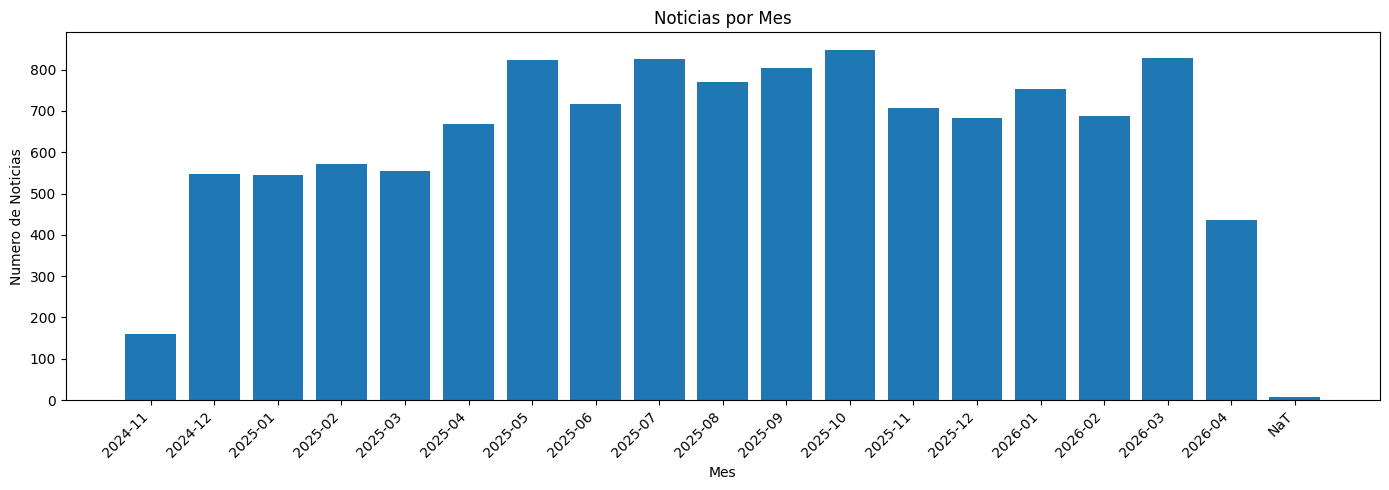

In [203]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14, 5))
plt.bar(noticias_por_mes["ano_mes"], noticias_por_mes["quantidade"])
plt.xlabel("Mes")
plt.ylabel("Numero de Noticias")
plt.title("Noticias por Mes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()